# Surface sensitivities in RMG and Cantera

In [1]:
import os
import rmgpy.chemkin
import rmgpy.solver
import rmgpy.rmg.listener
import rmgpy.rmg.settings

import cantera as ct

import numpy as np

import scipy.interpolate


import matplotlib.pyplot as plt
%matplotlib inline

# Load mechanisms for RMG and Cantera

Be careful when comparing surface mechanisms across RMG and Cantera because there are some edge cases where the kinetics RMG exports do not match what gets read into Cantera. See https://github.com/ReactionMechanismGenerator/RMG-Py/issues/2923 for more info.

This example mechanism was carefully checked and does not contain those edge cases.

In [2]:
chemkin = './chem_annotated-gas.inp'
chemkin_surface = './chem_annotated-surface.inp'
spec_dict = './species_dictionary.txt'
species_list, reaction_list = rmgpy.chemkin.load_chemkin_file(chemkin, spec_dict, surface_path=chemkin_surface)

mech_yaml = './chem_annotated.yaml'
gas = ct.Solution(mech_yaml)
surf = ct.Interface(mech_yaml, "SURF0", [gas])


# Define the initial conditions to be used for both RMG and Cantera

In [3]:
def get_i_thing_rmg(thing, thing_list):
    for i in range(len(thing_list)):
        if thing.is_isomorphic(thing_list[i]):
            return i
    assert False


x_O2 = 3e-5  # reasonable match
x_CH4 = 1e-5
T = rmgpy.quantity.Quantity((900, 'K'))
P = rmgpy.quantity.Quantity((1, 'atm'))

surface_volume_ratio = rmgpy.quantity.Quantity((1.0, "m^-1"))  # TODO, try higher surface volume ratios
surface_site_density = rmgpy.quantity.Quantity((surf.site_density, "kmol/m^2"))  # read from Cantera yaml just to be sure these match

termination = rmgpy.solver.TerminationTime(rmgpy.quantity.Quantity((1.0, 's')))


Ar = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='[Ar]'), species_list)]
CH4 = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='C'), species_list)]
CO2  = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='O=C=O'), species_list)]
O2 = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='[O][O]'), species_list)]
H2 = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='[H][H]'), species_list)]
H2O = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='O'), species_list)]
X = species_list[get_i_thing_rmg(rmgpy.species.Species(smiles='*'), species_list)]

initial_gas_mole_fractions = {O2: x_O2, CH4: x_CH4, Ar: 1.0 - x_O2 - x_CH4}
initial_surface_coverages = {X: 1.0}


sensitive_species = [CO2, H2O]
for sp in sensitive_species:
    display(sp)

# Set up and run the RMG simulation with sensitivity

In [4]:
# Define the surface reactor
reaction_system = rmgpy.solver.surface.SurfaceReactor(
    T,
    P,
    n_sims=1,
    initial_gas_mole_fractions=initial_gas_mole_fractions,
    initial_surface_coverages=initial_surface_coverages,
    surface_volume_ratio=surface_volume_ratio,
    surface_site_density=surface_site_density,
    termination=[termination],
    sensitive_species=sensitive_species,
)

output_directory = './'
os.makedirs(os.path.join(output_directory, 'solver'), exist_ok=True)
reaction_system_index = 0
reaction_system.attach(rmgpy.rmg.listener.SimulationProfileWriter(output_directory, reaction_system_index, species_list))  # to save results

simulator_settings = rmgpy.rmg.settings.SimulatorSettings()  # defaults
model_settings = rmgpy.rmg.settings.ModelSettings(tol_move_to_core=1e5)  # tol_move_to_core isn't set by default which causes an error
# termination = rmgpy.solver.TerminationTime(rmgpy.quantity.Quantity((0.1, 's')))

# Save sensitivities to a CSV file
sens_worksheet = []
for spec in sensitive_species:
    csvfile_path = os.path.join(output_directory, 'solver',
                                'sensitivity_{0}_SPC_{1}.csv'.format(reaction_system_index + 1, spec.index))
    sens_worksheet.append(csvfile_path)


reaction_system.simulate(
    core_species=species_list,
    core_reactions=reaction_list,
    edge_species=[],
    edge_reactions=[],
    surface_species=[],
    surface_reactions=[],
    model_settings=model_settings,
    simulator_settings=simulator_settings,
    sensitivity=True,
    sens_worksheet=sens_worksheet,
)

# retrieve the data from the csv
# You could use pandas to get it more directly, but this is fine
simulation_outfile = os.path.join(output_directory, 'solver', f'simulation_1_{len(species_list):d}.csv')
times_rmg, conc_rmg = rmgpy.tools.plot.parse_csv_data(simulation_outfile)
data_labels_rmg = [d.label for d in conc_rmg]

# Run the same simulation in Cantera

### Quick check that all the reaction and species names match across RMG and Cantera

In [5]:
gas = ct.Solution(mech_yaml)
surf = ct.Interface(mech_yaml, "SURF0", [gas])

# check that the species and reactions match up between RMG and Cantera
assert len(species_list) == gas.n_species + surf.n_species
assert len(reaction_list) == gas.n_reactions + surf.n_reactions

for i in range(gas.n_species):
    assert str(species_list[i].to_chemkin()) == str(gas.species_names[i])
for i in range(surf.n_species):
    assert str(species_list[i + gas.n_species].to_chemkin()) == str(surf.species_names[i])

def same_reaction(rmg_rxn, ct_rxn):
    # really hacky way to do this, but whatever
    rmg_r = set([str(x.to_chemkin()) for x in rmg_rxn.reactants])
    rmg_p = set([str(x.to_chemkin()) for x in rmg_rxn.products])
    rmg_r = rmg_r - set(['Ar'])
    rmg_p = rmg_p - set(['Ar'])
    rmg_val = list(set(sorted(list(rmg_r) + list(rmg_p))))
    
    ct_r = set(ct_rxn.reactants.keys())
    ct_p = set(ct_rxn.products.keys())
    ct_val = list(set(sorted(list(ct_r) + list(ct_p))))
    return ct_val == rmg_val

for i in range(gas.n_reactions):
    assert same_reaction(reaction_list[i], gas.reactions()[i])
for i in range(surf.n_reactions):
    assert same_reaction(reaction_list[i + gas.n_reactions], surf.reactions()[i])


### Run the Cantera simulation with sensitivities (this can take a minute or two)

In [6]:
gas = ct.Solution(mech_yaml)
surf = ct.Interface(mech_yaml, "SURF0", [gas])


REACTOR_VOLUME = 8.314 * T.value_si / P.value_si
initial_gas_mole_fractions_ct = {x.to_chemkin(): v for x, v in initial_gas_mole_fractions.items()}
initial_surface_coverages_ct = {x.to_chemkin(): v for x, v in initial_surface_coverages.items()}

REACTOR_AREA = REACTOR_VOLUME * surface_volume_ratio.value_si

gas.TPX = T.value_si, P.value_si, initial_gas_mole_fractions_ct
gas_reactor = ct.IdealGasReactor(gas, energy='off')
gas_reactor.volume = REACTOR_VOLUME

surf.TP = T.value_si, P.value_si
surf.coverages = initial_surface_coverages_ct

surf_reactor = ct.ReactorSurface(surf, gas_reactor)
surf_reactor.area = REACTOR_AREA


sim = ct.ReactorNet([gas_reactor])
# sim.atol = 1e-18
# sim.rtol = 1e-12

times_ct = [sim.time]
volumes = [gas_reactor.volume]
pressures = [gas.P]
temperatures = [gas.T]
surf_concs = [surf.concentrations]
gas_mol_fracs = [gas.X]
gas_mass_fracs = [gas.Y]
surf_cov = [surf_reactor.coverages]
gas_masses = [gas_reactor.mass]
surf_density_mass = [surf.density_mass]



n_surf_reactions = len(reaction_list) - gas.n_reactions  # can't use surf.n_reactions here because surf could be None
n_surf_species = len(species_list) - gas.n_species  # can't use surf.n_species here because surf could be None
for i in range(gas.n_reactions):
    gas_reactor.add_sensitivity_reaction(i)
for i in range(n_surf_reactions):
    surf_reactor.add_sensitivity_reaction(i)
for i in range(gas.n_species):
    gas_reactor.add_sensitivity_species_enthalpy(i)

all_sensitivities = [np.zeros((len(species_list) + len(reaction_list), len(sensitive_species)))]
all_concentrations = [np.concatenate((gas_reactor.thermo.X.copy(), surf.concentrations / surf.site_density))]


while sim.time < termination.time.value_si:
    sim.step()
    times_ct.append(sim.time)
    volumes.append(gas_reactor.volume)
    pressures.append(gas.P)
    temperatures.append(gas.T)
    surf_cov.append(surf_reactor.coverages)
    surf_concs.append(surf.concentrations)
    gas_mass_fracs.append(gas.Y)
    gas_mol_fracs.append(gas.X)
    gas_masses.append(gas_reactor.mass)
    surf_density_mass.append(surf.density_mass)

    all_concentrations.append(np.concatenate((gas_reactor.thermo.X.copy(), surf.concentrations / surf.site_density)))
    sens_mat = np.zeros((len(species_list) + len(reaction_list), len(sensitive_species)))
    # record sensitivities
    for j in range(len(sensitive_species)):
        for i in range(gas.n_reactions):  # gas reactions
            sens_mat[i, j] = sim.sensitivity(sensitive_species[j].to_chemkin(), i)
        for i in range(gas.n_species):  # gas species
            sens_mat[len(reaction_list) + i, j] = sim.sensitivity(sensitive_species[j].to_chemkin(), len(reaction_list) + i) * 4.184 * 1e6  # convert from J/kmol to kcal / mol in denominator    
        for i in range(n_surf_reactions):  # surface reactions
            sens_mat[gas.n_reactions + i, j] = sim.sensitivity(sensitive_species[j].to_chemkin(), gas.n_reactions + i)
        # Not Yet Implemented in Cantera, so we set the values to nan for now and estimate manually later
        for i in range(n_surf_species):  # surface species
            # sens_mat[len(self.reaction_list) + gas.n_species + i, j] = net.sensitivity(sensitive_species[j].to_chemkin(), len(self.reaction_list) + gas.n_species + i) * 4.184 * 1e6  # convert from J/kmol to kcal / mol in denominator
            sens_mat[len(reaction_list) + gas.n_species + i, j] = np.nan

    all_sensitivities.append(sens_mat)
    


def perturb_species(species, DELTA_J_MOL=418.4):
    # takes in a Cantera species and makes a copy with the enthalpy offset change
    # Default of 418 J/mol equals 0.1 kcal/mol
    R = 8.3144598  # gas constant in J/mol
    # copy the species
    input_data = species.input_data.copy()
    increase = DELTA_J_MOL / R
    for i in range(len(input_data['thermo']['data'])):
        input_data['thermo']['data'][i][5] += increase
    new_species = ct.Species().from_dict(input_data)
    return new_species


gas_mol_fracs = np.array(gas_mol_fracs)
gas_mass_fracs = np.array(gas_mass_fracs)
all_concentrations = np.array(all_concentrations)
all_sensitivities = np.array(all_sensitivities)

# For the sensitvity plot, we only care about the final timepoint, so use brute force to estimate that
for z in range(surf.n_species):
    # save a copy of the original species and perturb the enthalpy by 0.1 kcal/mol
    original_species = ct.Species().from_dict(surf.species()[z].input_data.copy())
    DELTA_J_MOL = 418.4
    # DELTA_J_MOL = 4184
    perturbed_species = perturb_species(surf.species()[z], DELTA_J_MOL=DELTA_J_MOL)
    surf.modify_species(z, perturbed_species)

    # rerun the simulation for each surface species, really unfortunate that it has to be done this way
    gas.TPX = T.value_si, P.value_si, initial_gas_mole_fractions_ct
    gas_reactor = ct.IdealGasReactor(gas, energy='off')  # constant volume and isothermal to match surface reactor
    surf.TP = T.value_si, P.value_si
    surf.coverages = initial_surface_coverages_ct
    surf_reactor = ct.ReactorSurface(surf, gas_reactor, A=surface_volume_ratio.value_si)  # surface reactor with specified surface area to volume ratio
    net = ct.ReactorNet([gas_reactor])
    # net.atol = 1e-18
    # net.rtol = 1e-12

    # re-Run the simulation and use interpolation to map the concentrations onto the original times
    times2 = [net.time]
    concs2 = [gas_reactor.thermo.X]
    while net.time < termination.time.value_si:
        net.step()
        times2.append(net.time)
        concs2.append(gas_reactor.thermo.X)
        # concs2.append(gas_reactor.thermo.Y)

    concs2 = np.array(concs2)
    x = original_species.thermo.h(T.value_si)
    x_perturbed = surf.species()[z].thermo.h(T.value_si)

    for j in range(len(sensitive_species)):

        f = scipy.interpolate.interp1d(times2, concs2[:, species_list.index(sensitive_species[j]) - gas.n_species], fill_value='extrapolate')
        y_perturbed = f(times_ct)
        
        # compute sensitivity
        # y = all_concentrations[:, species_list.index(sensitive_species[j])]
        # y = gas_mass_fracs[:, species_list.index(sensitive_species[j])]
        y = gas_mol_fracs[:, species_list.index(sensitive_species[j])]
        
        if x == 0:
            sensitivity = np.zeros_like(times_ct) + np.nan
        else:
            # sensitivity = np.divide(y_perturbed - y, y) / ((x_perturbed - x) / x)
            sensitivity = np.divide(y_perturbed - y, y) / ((x_perturbed - x) / (4.184 * 1e6))
        all_sensitivities[:, len(reaction_list) + gas.n_species + z, j] = sensitivity
    # reset the species back to the original
    surf.modify_species(z, original_species)



times_ct = np.array(times_ct)
volumes = np.array(volumes)
pressures = np.array(pressures)
temperatures = np.array(temperatures)
surf_cov = np.array(surf_cov)
surf_concs = np.array(surf_concs)
gas_mol_fracs = np.array(gas_mol_fracs)
gas_mass_fracs = np.array(gas_mass_fracs)
gas_masses = np.array(gas_masses)
surf_density_mass = np.array(surf_density_mass)
all_sensitivities = np.array(all_sensitivities)

/tmp/ipykernel_251278/2549048414.py:148: RuntimeWarning: invalid value encountered in divide
  sensitivity = np.divide(y_perturbed - y, y) / ((x_perturbed - x) / (4.184 * 1e6))


# Plot gas concentrations

Text(0.5, 1.0, 'Concentrations vs. Time')

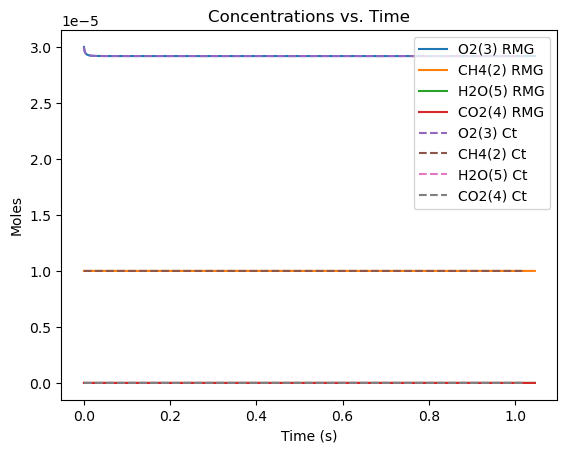

In [7]:
top_N = 5

# ------------------------ RMG -------------------
assert 'volume' in data_labels_rmg[0].lower()
rmg_volume = conc_rmg[0].data

n_mols_rmg = np.array([d.data for d in conc_rmg[1:]]).T
n_gas_rmg = np.sum([not x.contains_surface_site() for x in species_list])
n_surf_rmg = np.sum([x.contains_surface_site() for x in species_list])

# sort to get the top concentrations
max_conc = np.max(n_mols_rmg[:, :n_gas_rmg], axis=0)
indices = np.arange(n_gas_rmg)
sorted_order = [x for _, x in sorted(zip(max_conc, indices))][::-1]
for i in range(top_N):
    j = sorted_order[i]
    if Ar.to_chemkin() in data_labels_rmg[j + 1]:
        continue
    plt.plot(times_rmg.data, n_mols_rmg[:, j], label=data_labels_rmg[j + 1] + ' RMG')

# ------------------------ Cantera -------------------
max_conc = np.max(gas_mol_fracs, axis=0)
indices = np.arange(gas.n_species)
sorted_order = [x for _, x in sorted(zip(max_conc, indices))][::-1]
ct_labels = gas.species_names + gas.reaction_equations()
for i in range(top_N):
    j = sorted_order[i]
    if Ar.to_chemkin() in ct_labels[j]:
        continue
    plt.plot(times_ct, gas_mol_fracs[:, j], label=ct_labels[j] + ' Ct', linestyle='dashed')


plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Moles')
plt.title('Concentrations vs. Time')



# TODO Plot surface concentrations

# Plot sensitivity for a specific reaction

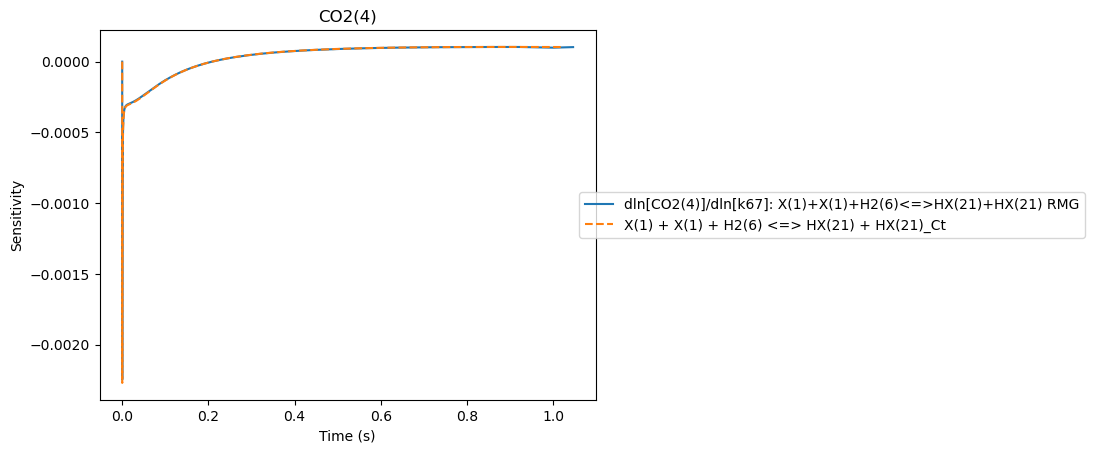

In [8]:
reaction_index = gas.n_reactions + 2

i_spec = 0
spec = sensitive_species[i_spec]
# RMG sensitivity
csvfile_path = os.path.join(output_directory, 'solver',
                            'sensitivity_{0}_SPC_{1}.csv'.format(reaction_system_index + 1, spec.index))
times_rmg, data_sens = rmgpy.tools.plot.parse_csv_data(csvfile_path)
data_labels_sens = [d.label for d in data_sens]

species_name = rmgpy.chemkin.get_species_identifier(sensitive_species[i_spec])
my_reaction_label = 'dln[{0}]/dln[k{1}]: {2}'.format(species_name, reaction_index + 1, reaction_list[reaction_index].to_chemkin(kinetics=False))

plt.plot(times_rmg.data, data_sens[data_labels_sens.index(my_reaction_label)].data, label=my_reaction_label + ' RMG')


# Cantera sensitivities

sensitivity_labels = [str(x) for x in reaction_list] + [str(x) for x in species_list]
plt.plot(times_ct, all_sensitivities[:, reaction_index, i_spec], label=sensitivity_labels[reaction_index] + '_Ct', linestyle='dashed')



plt.legend(loc='right', bbox_to_anchor=(2.0, 0.5))

# plt.xscale('log')

plt.title(spec)
plt.xlabel('Time (s)')
plt.ylabel('Sensitivity')
plt.show()

# Plot sensitivity for a particular species

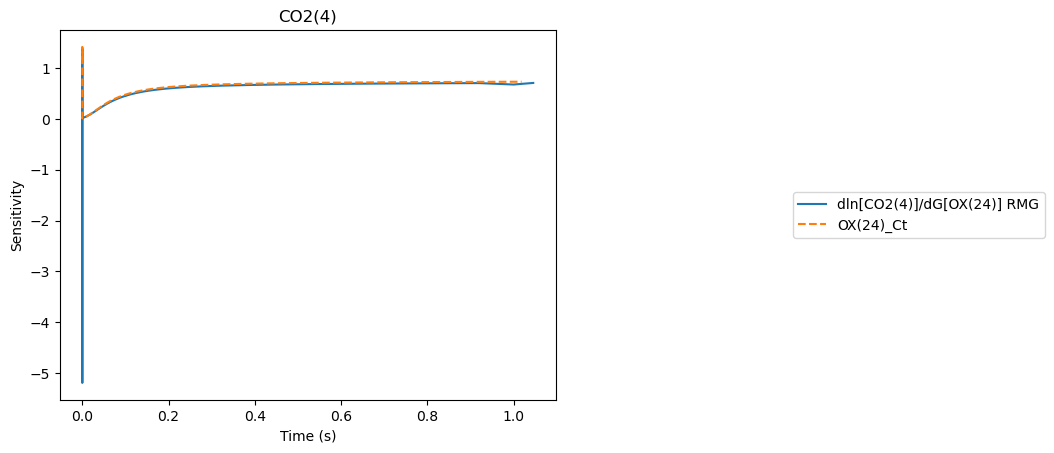

In [9]:
species_index = gas.n_species + 4

i_spec = 0
spec = sensitive_species[i_spec]
# RMG sensitivity
csvfile_path = os.path.join(output_directory, 'solver',
                            'sensitivity_{0}_SPC_{1}.csv'.format(reaction_system_index + 1, spec.index))
times_rmg, data_sens = rmgpy.tools.plot.parse_csv_data(csvfile_path)
data_labels_sens = [d.label for d in data_sens]

species_name = rmgpy.chemkin.get_species_identifier(sensitive_species[i_spec])
my_species_label = 'dln[{0}]/dG[{1}]'.format(species_name, rmgpy.chemkin.get_species_identifier(species_list[species_index]))

plt.plot(times_rmg.data, data_sens[data_labels_sens.index(my_species_label)].data, label=my_species_label + ' RMG')


# Cantera sensitivities
K = 40
sensitivity_labels = [str(x) for x in reaction_list] + [str(x) for x in species_list]
plt.plot(times_ct[K:], all_sensitivities[K:, len(reaction_list) + species_index, i_spec], label=sensitivity_labels[len(reaction_list) + species_index] + '_Ct', linestyle='dashed')

# plt.xlim([1e-12, 1e0])

plt.legend(loc='right', bbox_to_anchor=(2.0, 0.5))

# plt.xscale('log')

plt.title(spec)
plt.xlabel('Time (s)')
plt.ylabel('Sensitivity')
plt.show()

# Plot the top reaction sensitivities

/tmp/ipykernel_251278/2736667656.py:20: RuntimeWarning: All-NaN slice encountered
  max_conc = np.nanmax(np.abs(all_sensitivities[:, :, i_spec]), axis=0)


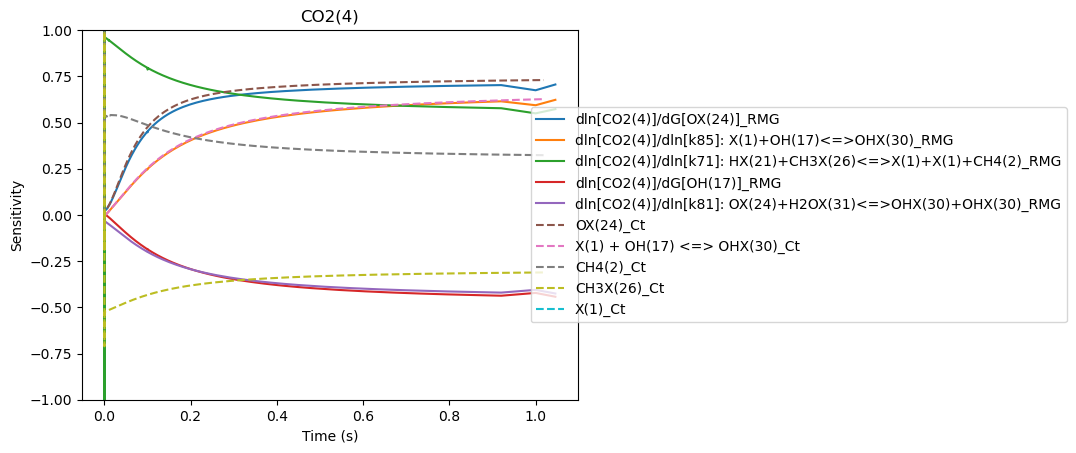

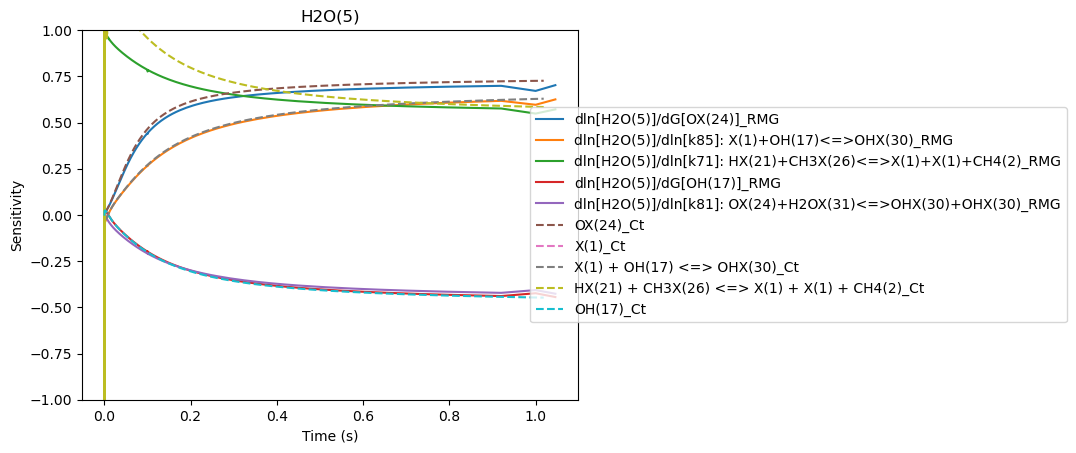

In [10]:
top_N = 5
for i_spec, spec in enumerate(sensitive_species):
    # RMG sensitivities
    csvfile_path = os.path.join(output_directory, 'solver',
                                'sensitivity_{0}_SPC_{1}.csv'.format(reaction_system_index + 1, spec.index))
    times_rmg, data_sens = rmgpy.tools.plot.parse_csv_data(csvfile_path)
    data_labels_sens = [d.label for d in data_sens]

    sens_mat = np.array([d.data for d in data_sens]).T
    # max_conc = np.max(np.abs(sens_mat), axis=0)
    indices = np.arange(sens_mat.shape[1])
    sorted_order = [x for _, x in sorted(zip(np.abs(sens_mat[-1, :]), indices))][::-1]
    for i in range(top_N):
        j = sorted_order[i]
        plt.plot(times_rmg.data, sens_mat[:, j], label=data_labels_sens[j] + '_RMG')
        

    # Cantera sensitivities
    
    max_conc = np.nanmax(np.abs(all_sensitivities[:, :, i_spec]), axis=0)
    indices = np.arange(all_sensitivities.shape[1])
    sorted_order = [x for _, x in sorted(zip(np.abs(all_sensitivities[-1, :, i_spec]), indices))][::-1]
    sensitivity_labels = [str(x) for x in reaction_list] + [str(x) for x in species_list]
    for i in range(top_N):
        j = sorted_order[i]
        plt.plot(times_ct, all_sensitivities[:, j, i_spec], label=sensitivity_labels[j] + '_Ct', linestyle='dashed')
        # plt.plot(times_ct, all_sensitivities[:, i, i_spec], label=sensitivity_labels[i] + '_Ct', linestyle='dashed')
        
    plt.ylim([-1, 1])
    
    plt.legend(loc='right', bbox_to_anchor=(2.0, 0.5))


    
    plt.title(spec)
    plt.xlabel('Time (s)')
    plt.ylabel('Sensitivity')
    plt.show()